# Rope Flow — Data-Driven 3D Trajectory Reconstruction

## Overview

This notebook implements the full trajectory reconstruction pipeline for IMU-based rope flow analysis, following a three-stage methodology.

| Stage | Method 
|-------|--------
| **2A** | SINDy — discover governing dynamics from data
| **2B** | PINN — inverse problem: reconstruct trajectory under physics constraints
| **2C** | DMD + Autoencoder — extract modes for pattern recognition 


---
## 0. Setup & Data Loading

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
from mpl_toolkits.mplot3d import Axes3D
from scipy import signal, integrate
from scipy.linalg import svd
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
import pysindy as ps
import warnings
warnings.filterwarnings('ignore')
import glob, os

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
C = {
    'dev0':  '#5DCAA5',
    'dev1':  '#7F77DD',
    'naive': '#E24B4A',
    'pinn':  '#EF9F27',
    'recon': '#378ADD',
    'gray':  '#888780',
}

print('pysindy version:', ps.__version__)
print('torch version  :', torch.__version__)

pysindy version: 2.1.0
torch version  : 2.10.0+cpu


In [46]:
# Load processed data — update paths as needed
data_dir = '../../data/processed'
csv_files = sorted(glob.glob(os.path.join(data_dir, '*.csv')))

# Pair files by shared session name: device0 and device1
d0 = pd.read_csv([f for f in csv_files if 'device0' in f][0])
d1 = pd.read_csv([f for f in csv_files if 'device1' in f][0])

print(f'Device 0: {os.path.basename([f for f in csv_files if "device0" in f][0])}')
print(f'Device 1: {os.path.basename([f for f in csv_files if "device1" in f][0])}')

Device 0: 20260121_160212_unnamed_device0_processed.csv
Device 1: 20260121_160212_unnamed_device1_processed.csv


In [47]:
def preprocess(df):
    """
    Extract signals from dataframe and derive angular velocity from quaternion.

    Returns
    -------
    t     : (N,)   time in seconds
    Q     : (N,4)  quaternion [qw, qx, qy, qz]
    A     : (N,3)  world-frame linear acceleration [m/s2]
    omega : (N,3)  angular velocity derived from quaternion [rad/s]
    """
    t = df['timestamp_ms'].values / 1000.0
    Q = df[['qw','qx','qy','qz']].values
    A = df[['ax_w','ay_w','az_w']].values

    # Angular velocity in body frame: omega = 2 * q_conj ⊗ dq/dt
    dQ = np.gradient(Q, t, axis=0)
    qw, qx, qy, qz = Q[:,0], Q[:,1], Q[:,2], Q[:,3]
    omega = np.column_stack([
        2*(-qx*dQ[:,0] + qw*dQ[:,1] + qz*dQ[:,2] - qy*dQ[:,3]),
        2*(-qy*dQ[:,0] - qz*dQ[:,1] + qw*dQ[:,2] + qx*dQ[:,3]),
        2*(-qz*dQ[:,0] + qy*dQ[:,1] - qx*dQ[:,2] + qw*dQ[:,3]),
    ])
    return t, Q, A, omega

t0, Q0, A0, om0 = preprocess(d0)
t1, Q1, A1, om1 = preprocess(d1)
print('State matrix shapes:', np.hstack([A0, om0]).shape, np.hstack([A1, om1]).shape)

State matrix shapes: (2254, 6) (2256, 6)


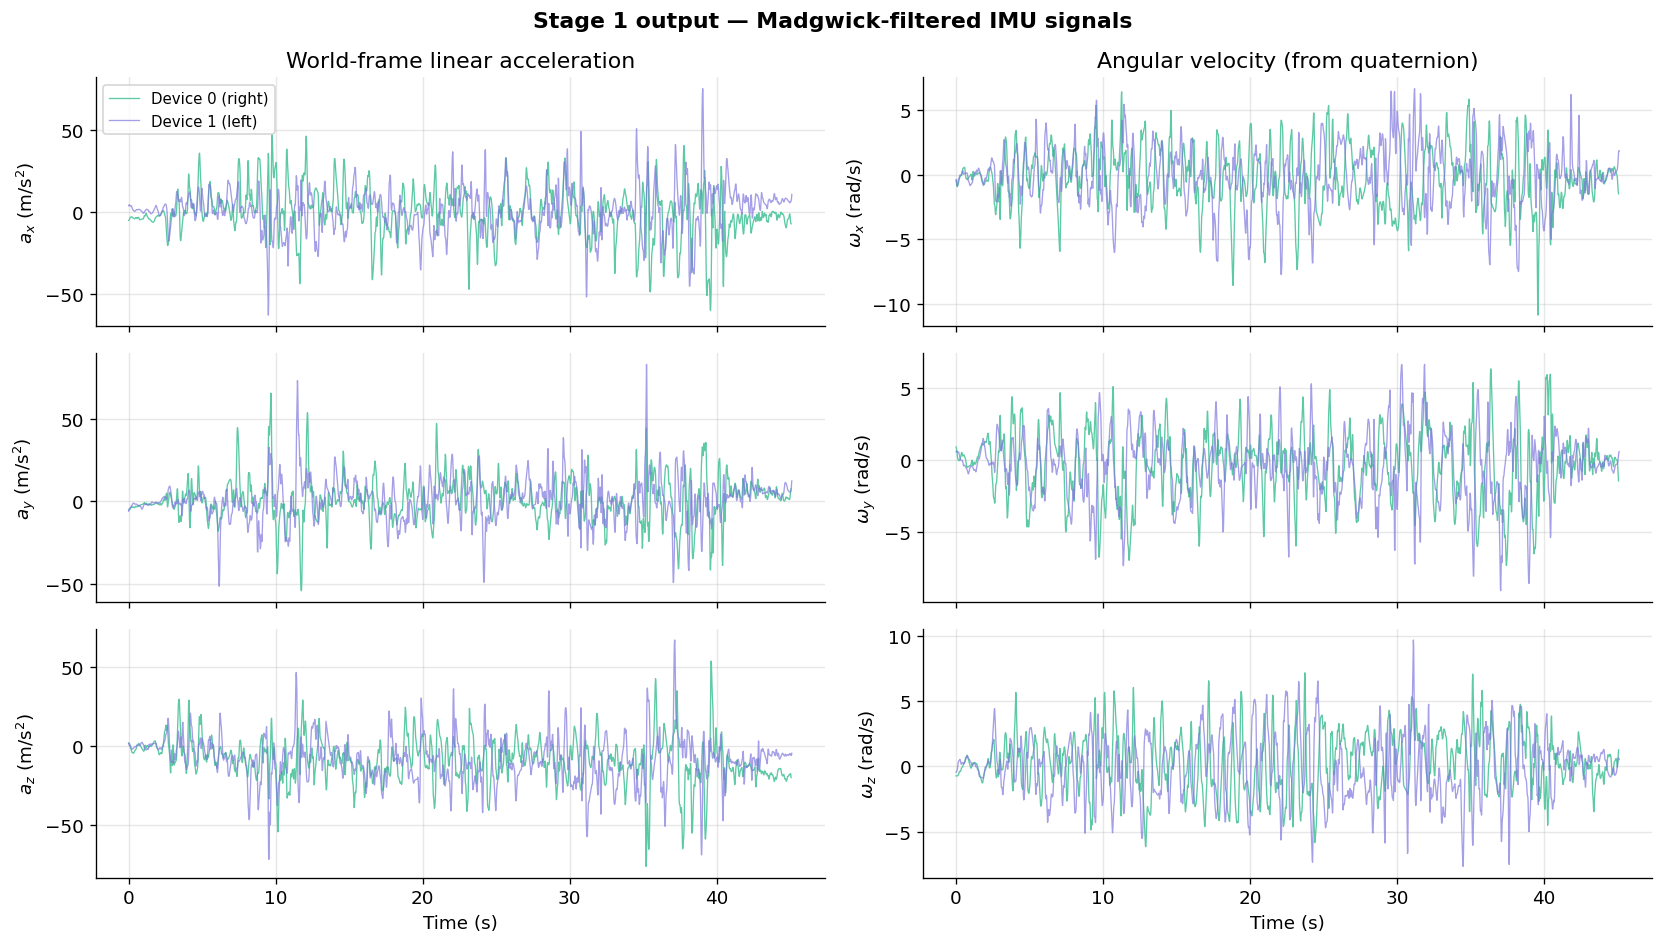

In [48]:
fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharex=True)
a_labels = ['$a_x$ (m/s$^2$)', '$a_y$ (m/s$^2$)', '$a_z$ (m/s$^2$)']
o_labels = ['$\\omega_x$ (rad/s)', '$\\omega_y$ (rad/s)', '$\\omega_z$ (rad/s)']

for i in range(3):
    axes[i,0].plot(t0, A0[:,i],  color=C['dev0'], lw=0.8, label='Device 0 (right)')
    axes[i,0].plot(t1, A1[:,i],  color=C['dev1'], lw=0.8, alpha=0.7, label='Device 1 (left)')
    axes[i,0].set_ylabel(a_labels[i])
    axes[i,1].plot(t0, om0[:,i], color=C['dev0'], lw=0.8)
    axes[i,1].plot(t1, om1[:,i], color=C['dev1'], lw=0.8, alpha=0.7)
    axes[i,1].set_ylabel(o_labels[i])

axes[0,0].set_title('World-frame linear acceleration')
axes[0,1].set_title('Angular velocity (from quaternion)')
axes[0,0].legend(fontsize=9)
for ax in axes[-1]:
    ax.set_xlabel('Time (s)')
plt.suptitle('Stage 1 output — Madgwick-filtered IMU signals', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_01_signal_overview.png', bbox_inches='tight')
plt.show()

### 0.1 — Cycle Segmentation

Segmenting the signal into individual rope flow cycles is the most critical preprocessing step: it bounds the temporal window of drift accumulation and gives SINDy a stationary training set.

We detect cycle boundaries from peaks in the angular velocity magnitude $\|\boldsymbol{\omega}(t)\|$, which marks the high-speed phase at the top of each revolution.

In [49]:
def detect_cycles(t, omega, min_period=0.5, prominence=1.5, label=''):
    """
    Detect rope-flow cycle boundaries from angular velocity magnitude peaks.
    Boundaries are placed at midpoints between consecutive peaks.

    Returns
    -------
    cycles       : list of (start_idx, end_idx)
    omega_smooth : smoothed magnitude signal
    peaks        : indices of detected peaks
    """
    omega_mag    = np.linalg.norm(omega, axis=1)
    omega_smooth = signal.savgol_filter(omega_mag, window_length=11, polyorder=3)
    sr           = 1.0 / np.median(np.diff(t))

    peaks, _ = signal.find_peaks(
        omega_smooth,
        distance=int(min_period * sr),
        prominence=prominence
    )
    bounds = [0] + [(peaks[i]+peaks[i+1])//2 for i in range(len(peaks)-1)] + [len(t)-1]
    cycles = [(bounds[i], bounds[i+1]) for i in range(len(bounds)-1)]

    durations = [t[e]-t[s] for s,e in cycles]
    print(f'{label}: {len(peaks)} peaks -> {len(cycles)} cycles | '
          f'mean T = {np.mean(durations):.2f}s +/- {np.std(durations):.2f}s')
    return cycles, omega_smooth, peaks

cycles0, om0_smooth, peaks0 = detect_cycles(t0, om0, label='Device 0')
cycles1, om1_smooth, peaks1 = detect_cycles(t1, om1, label='Device 1')

Device 0: 49 peaks -> 49 cycles | mean T = 0.92s +/- 0.41s
Device 1: 46 peaks -> 46 cycles | mean T = 0.98s +/- 0.41s


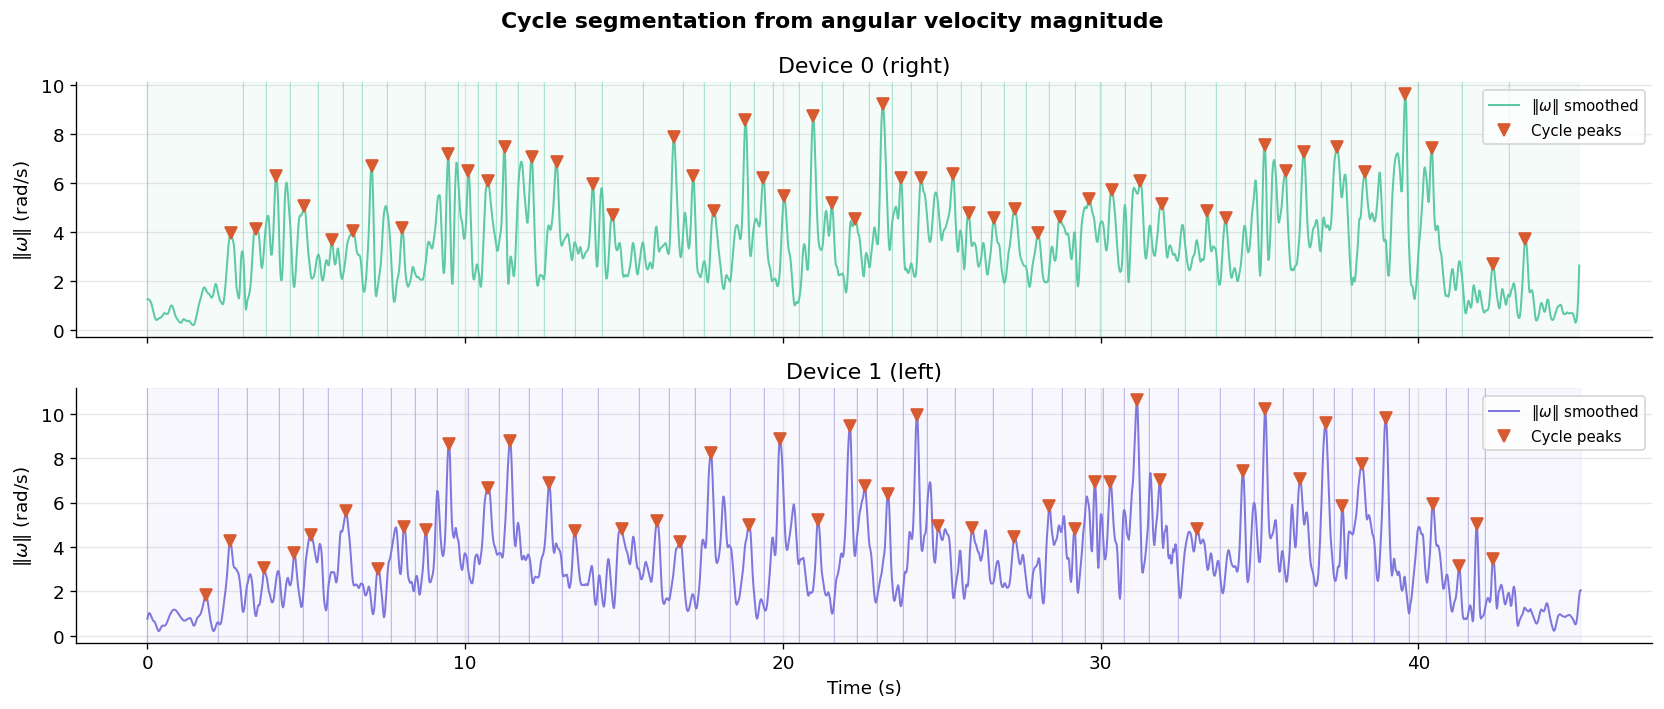

In [50]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for ax, t, sm, pks, cycs, label, col in [
    (axes[0], t0, om0_smooth, peaks0, cycles0, 'Device 0 (right)', C['dev0']),
    (axes[1], t1, om1_smooth, peaks1, cycles1, 'Device 1 (left)',  C['dev1']),
]:
    ax.plot(t, sm, color=col, lw=1.2, label='$\\|\\omega\\|$ smoothed')
    ax.plot(t[pks], sm[pks], 'v', color='#D85A30', ms=7, label='Cycle peaks')
    for s,e in cycs:
        ax.axvspan(t[s], t[e], alpha=0.06, color=col)
        ax.axvline(t[s], color=col, lw=0.6, alpha=0.4)
    ax.set_ylabel('$\\|\\omega\\|$ (rad/s)')
    ax.set_title(label)
    ax.legend(fontsize=9, loc='upper right')
axes[-1].set_xlabel('Time (s)')
plt.suptitle('Cycle segmentation from angular velocity magnitude', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_02_cycle_detection.png', bbox_inches='tight')
plt.show()

---
## Stage 2A — SINDy: Sparse Identification of Nonlinear Dynamics

**Goal**: Discover the governing equations of hand dynamics from data — without assuming a model.

**State vector** (signal space, no integration needed):
$$\mathbf{x}(t) = [a_x,\, a_y,\, a_z,\, \omega_x,\, \omega_y,\, \omega_z]^\top \in \mathbb{R}^6$$

**SINDy formulation** (Brunton et al., PNAS 2016):
$$\dot{\mathbf{x}} = \Theta(\mathbf{x})\,\Xi$$

where $\Theta(\mathbf{x})$ is a candidate feature library (polynomial + Fourier terms) and $\Xi$ is a **sparse** coefficient matrix recovered via STLSQ.

**Why Fourier terms?** Rope flow is periodic — $\sin/\cos$ terms capture oscillatory couplings that polynomials alone represent poorly.

**Link to Stage 2B**: The sparse equations SINDy discovers become the physics prior in the PINN loss function, grounding the reconstruction in data-identified dynamics rather than assumed kinematics.

In [51]:
X0 = np.hstack([A0, om0])   # (N, 6) full state matrix
X1 = np.hstack([A1, om1])
state_names = ['ax', 'ay', 'az', 'wx', 'wy', 'wz']
dt_s = float(np.median(np.diff(t0)))

print(f'State matrix: {X0.shape}  |  dt = {dt_s*1000:.1f} ms')

State matrix: (2254, 6)  |  dt = 20.0 ms


In [52]:
# Build feature library: polynomial degree-2 + Fourier (sin/cos)
poly_lib    = ps.PolynomialLibrary(degree=2, include_bias=True)
fourier_lib = ps.FourierLibrary(n_frequencies=1)
library     = ps.GeneralizedLibrary([poly_lib, fourier_lib])

# STLSQ optimizer — we sweep threshold below
optimizer = ps.STLSQ(threshold=0.1, alpha=0.05, max_iter=20)

# Smoothed finite differences — robust to IMU noise
differentiator = ps.SmoothedFiniteDifference(smoother_kws={'window_length': 11})

model = ps.SINDy(
    feature_library=library,
    optimizer=optimizer,
    differentiation_method=differentiator,
)
model.fit(X0, t=t0)

print('=== Discovered equations (threshold=0.1) ===')
model.print()
print(f'\nLibrary size: {model.n_features_in_} terms')

=== Discovered equations (threshold=0.1) ===
(x0)' = -2.640 1 + -0.425 x0 +  0.763 x1 + -1.043 x2 +  4.595 x3 + -2.778 x4 +  0.196 x0 x3 +  0.272 x0 x4 +  0.331 x0 x5 +  0.309 x1 x5 + -0.905 x2 x4 +  0.613 x3^2 +  3.429 x3 x5 + -0.716 x4^2 + -1.241 x4 x5 + -0.239 sin(1 x0) + -2.019 cos(1 x0) + -4.069 sin(1 x1) + -5.747 cos(1 x1) +  3.372 sin(1 x2) + -3.081 cos(1 x2) +  4.161 sin(1 x3) + -4.613 cos(1 x3) + -20.517 sin(1 x4) +  5.381 cos(1 x4) +  16.289 sin(1 x5) + -18.897 cos(1 x5)
(x1)' = -11.299 1 + -0.232 x0 +  0.385 x1 + -2.726 x3 +  4.603 x4 +  6.425 x5 + -0.244 x0 x3 +  0.216 x1 x3 +  0.480 x1 x4 +  0.854 x1 x5 +  0.252 x2 x3 +  0.310 x2 x4 + -0.409 x2 x5 +  0.531 x3^2 + -0.381 x3 x4 + -0.399 x4^2 + -0.179 x4 x5 +  1.721 x5^2 +  0.364 sin(1 x0) +  2.077 cos(1 x0) +  4.176 sin(1 x1) + -0.632 cos(1 x1) +  5.595 sin(1 x2) + -0.855 cos(1 x2) +  7.794 sin(1 x3) +  0.375 cos(1 x3) +  7.164 sin(1 x4) +  4.764 cos(1 x4) + -3.680 sin(1 x5) +  7.315 cos(1 x5)
(x2)' = -14.030 1 +  1.331 x0 +

### 2A.1 — Threshold Sweep: Pareto Front (Sparsity vs Accuracy)

In [53]:
thresholds   = [0.02, 0.05, 0.1, 0.2, 0.4, 0.8]
sindy_sweep  = {}

for th in thresholds:
    m = ps.SINDy(
        feature_library=ps.GeneralizedLibrary([
            ps.PolynomialLibrary(degree=2, include_bias=True),
            ps.FourierLibrary(n_frequencies=1)
        ]),
        optimizer=ps.STLSQ(threshold=th, alpha=0.05, max_iter=20),
        differentiation_method=ps.SmoothedFiniteDifference(
            smoother_kws={'window_length': 11}),
    )
    m.fit(X0, t=t0)
    r2       = m.score(X0, t=t0)
    coef     = m.coefficients()
    sparsity = (coef == 0).mean()
    n_active = int((coef != 0).sum())
    sindy_sweep[th] = {'model': m, 'r2': r2, 'sparsity': sparsity, 'n_active': n_active}
    print(f'threshold={th:.2f}  R2={r2:.4f}  sparsity={sparsity:.1%}  active={n_active}')

BEST_TH   = 0.1
best_model = sindy_sweep[BEST_TH]['model']
print(f'\nSelected threshold: {BEST_TH}')

threshold=0.02  R2=0.1300  sparsity=16.2%  active=201
threshold=0.05  R2=0.1147  sparsity=32.5%  active=162
threshold=0.10  R2=0.1011  sparsity=38.8%  active=147
threshold=0.20  R2=0.0909  sparsity=50.8%  active=118
threshold=0.40  R2=0.0669  sparsity=65.0%  active=84
threshold=0.80  R2=0.0303  sparsity=77.5%  active=54

Selected threshold: 0.1


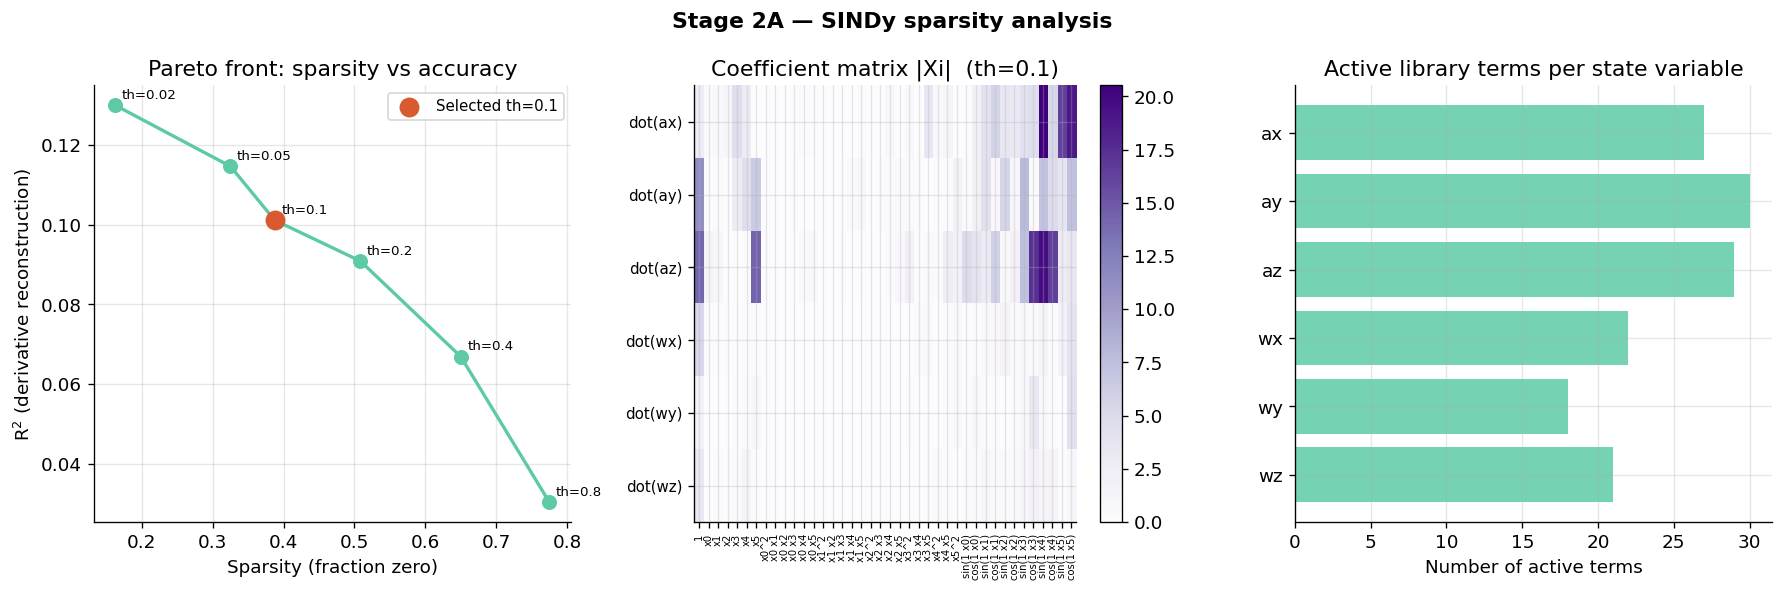

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Pareto front
ths  = list(sindy_sweep.keys())
r2s  = [sindy_sweep[t]['r2']       for t in ths]
sprs = [sindy_sweep[t]['sparsity'] for t in ths]

axes[0].plot(sprs, r2s, 'o-', color=C['dev0'], ms=8, lw=2)
for th, s, r in zip(ths, sprs, r2s):
    axes[0].annotate(f'th={th}', (s,r), textcoords='offset points', xytext=(4,4), fontsize=8)
axes[0].scatter([sindy_sweep[BEST_TH]['sparsity']],
               [sindy_sweep[BEST_TH]['r2']],
               color='#D85A30', s=120, zorder=5, label=f'Selected th={BEST_TH}')
axes[0].set_xlabel('Sparsity (fraction zero)')
axes[0].set_ylabel('R$^2$ (derivative reconstruction)')
axes[0].set_title('Pareto front: sparsity vs accuracy')
axes[0].legend(fontsize=9)

# Coefficient heatmap
coef       = best_model.coefficients()      # (n_states, n_features)
feat_names = best_model.get_feature_names()
im = axes[1].imshow(np.abs(coef), aspect='auto', cmap='Purples', interpolation='nearest')
axes[1].set_xticks(range(len(feat_names)))
axes[1].set_xticklabels(feat_names, rotation=90, fontsize=6)
axes[1].set_yticks(range(len(state_names)))
axes[1].set_yticklabels([f'dot({s})' for s in state_names], fontsize=9)
axes[1].set_title(f'Coefficient matrix |Xi|  (th={BEST_TH})')
plt.colorbar(im, ax=axes[1])

# Active terms per state
n_active_state = (coef != 0).sum(axis=1)
axes[2].barh(state_names, n_active_state, color=C['dev0'], alpha=0.85)
axes[2].set_xlabel('Number of active terms')
axes[2].set_title('Active library terms per state variable')
axes[2].invert_yaxis()

plt.suptitle('Stage 2A — SINDy sparsity analysis', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_03_sindy_sparsity.png', bbox_inches='tight')
plt.show()

### 2A.2 — Discovered Equations, Simulation & Cross-Device Generalisation

=== DISCOVERED EQUATIONS (threshold=0.1) ===
(x0)' = -2.640 1 + -0.425 x0 +  0.763 x1 + -1.043 x2 +  4.595 x3 + -2.778 x4 +  0.196 x0 x3 +  0.272 x0 x4 +  0.331 x0 x5 +  0.309 x1 x5 + -0.905 x2 x4 +  0.613 x3^2 +  3.429 x3 x5 + -0.716 x4^2 + -1.241 x4 x5 + -0.239 sin(1 x0) + -2.019 cos(1 x0) + -4.069 sin(1 x1) + -5.747 cos(1 x1) +  3.372 sin(1 x2) + -3.081 cos(1 x2) +  4.161 sin(1 x3) + -4.613 cos(1 x3) + -20.517 sin(1 x4) +  5.381 cos(1 x4) +  16.289 sin(1 x5) + -18.897 cos(1 x5)
(x1)' = -11.299 1 + -0.232 x0 +  0.385 x1 + -2.726 x3 +  4.603 x4 +  6.425 x5 + -0.244 x0 x3 +  0.216 x1 x3 +  0.480 x1 x4 +  0.854 x1 x5 +  0.252 x2 x3 +  0.310 x2 x4 + -0.409 x2 x5 +  0.531 x3^2 + -0.381 x3 x4 + -0.399 x4^2 + -0.179 x4 x5 +  1.721 x5^2 +  0.364 sin(1 x0) +  2.077 cos(1 x0) +  4.176 sin(1 x1) + -0.632 cos(1 x1) +  5.595 sin(1 x2) + -0.855 cos(1 x2) +  7.794 sin(1 x3) +  0.375 cos(1 x3) +  7.164 sin(1 x4) +  4.764 cos(1 x4) + -3.680 sin(1 x5) +  7.315 cos(1 x5)
(x2)' = -14.030 1 +  1.331 x0 +

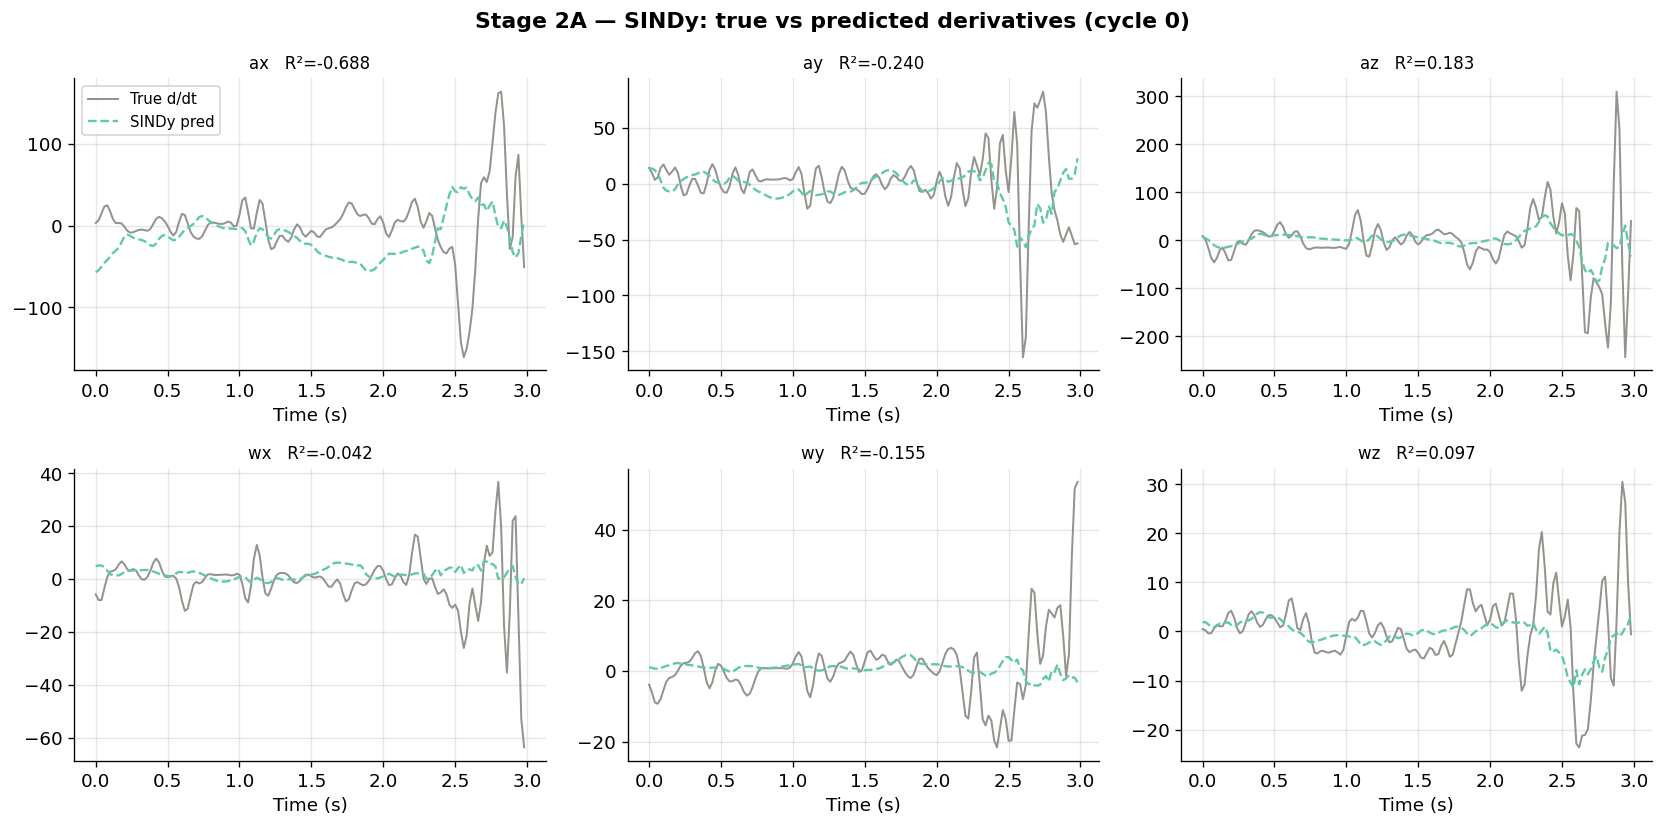

Cross-device R2 check:
  Device 0 (train): 0.1011
  Device 1 (unseen): -0.1852

If R2 generalises well, the equations reflect true rope-flow dynamics,
not sensor-specific artefacts.


In [55]:
print('=== DISCOVERED EQUATIONS (threshold={}) ==='.format(BEST_TH))
best_model.print()
print()

# Simulate from cycle 0 initial condition
s0, e0  = cycles0[0]
t_cyc   = t0[s0:e0]
X_cyc   = X0[s0:e0]
# Replaced simulate() with derivative reconstruction — much faster and more reliable
dX0_pred = best_model.predict(X_cyc)   # predicted derivatives, no ODE solving

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for i, (ax, name) in enumerate(zip(axes.flat, state_names)):
    ax.plot(t_cyc, np.gradient(X_cyc[:, i], t_cyc), color=C['gray'], lw=1.2, alpha=0.9, label='True d/dt')
    ax.plot(t_cyc, dX0_pred[:, i],                  color=C['dev0'], lw=1.4, ls='--',   label='SINDy pred')
    r2 = 1 - np.var(np.gradient(X_cyc[:,i], t_cyc) - dX0_pred[:,i]) / \
             (np.var(np.gradient(X_cyc[:,i], t_cyc)) + 1e-10)
    ax.set_title(f'{name}   R²={r2:.3f}', fontsize=10)
    ax.set_xlabel('Time (s)')
axes[0,0].legend(fontsize=9)
plt.suptitle('Stage 2A — SINDy: true vs predicted derivatives (cycle 0)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_04_sindy_simulation.png', bbox_inches='tight')
plt.show()

# Cross-device generalisation
r2_d0 = best_model.score(X0, t=t0)
r2_d1 = best_model.score(X1, t=t1)
print(f'Cross-device R2 check:')
print(f'  Device 0 (train): {r2_d0:.4f}')
print(f'  Device 1 (unseen): {r2_d1:.4f}')
print()
print('If R2 generalises well, the equations reflect true rope-flow dynamics,')
print('not sensor-specific artefacts.')

---
## Stage 2B — PINN: Trajectory Reconstruction as an Inverse Problem

**Goal**: Recover per-cycle 3D position $\mathbf{p}(t) \in \mathbb{R}^3$ from IMU observations, using the SINDy dynamics as physics prior.

**Inverse problem framing**: Given noisy $\hat{\mathbf{a}}(t)$, find $\mathbf{p}(t)$ satisfying:
- $\ddot{\mathbf{p}}(t) \approx \hat{\mathbf{a}}(t)$ — data consistency
- Boundary constraint: $\text{ReLU}(\|\mathbf{p}-\mathbf{p}_{\text{shoulder}}\| - R_{\text{arm}})^2$
- Periodicity: $\|\mathbf{p}(T) - \mathbf{p}(0)\|^2 \approx 0$
- Jerk minimisation: $\int \|\dddot{\mathbf{p}}\|^2\,dt$

**Corrector strategy**: Compute naive double-integrated $\mathbf{p}_{\text{naive}}(t)$, then train PINN to learn correction $\delta\mathbf{p}(t)$ such that $\mathbf{p} = \mathbf{p}_{\text{naive}} + \delta\mathbf{p}$ minimises the composite loss.

**Self-supervised validation**: Periodicity residual $\|\mathbf{p}(T) - \mathbf{p}(0)\|$ — no ground truth required.

### 2B.1 — Naive Double Integration (Baseline)

In [56]:
def naive_integrate(t, A, s, e):
    """Cumulative trapezoidal double-integration within one cycle."""
    tc, Ac = t[s:e], A[s:e]
    v = np.column_stack([
        integrate.cumulative_trapezoid(Ac[:,d], tc, initial=0) for d in range(3)
    ])
    p = np.column_stack([
        integrate.cumulative_trapezoid(v[:,d],  tc, initial=0) for d in range(3)
    ])
    return tc, v, p

naive_cycs  = []
for s, e in cycles0:
    tc, vc, pc = naive_integrate(t0, A0, s, e)
    naive_cycs.append({'t': tc, 'v': vc, 'p': pc, 's': s, 'e': e})

naive_drift = [np.linalg.norm(c['p'][-1] - c['p'][0]) for c in naive_cycs]
print('Naive integration — periodicity drift |p(T)-p(0)|:')
for k, d in enumerate(naive_drift):
    print(f'  Cycle {k}: {d:.4f} m')
print(f'  Mean: {np.mean(naive_drift):.4f} m  <- baseline to beat')

Naive integration — periodicity drift |p(T)-p(0)|:
  Cycle 0: 20.2908 m
  Cycle 1: 0.7651 m
  Cycle 2: 1.6415 m
  Cycle 3: 3.9114 m
  Cycle 4: 3.3598 m
  Cycle 5: 1.9351 m
  Cycle 6: 3.8022 m
  Cycle 7: 7.5679 m
  Cycle 8: 7.9598 m
  Cycle 9: 5.3158 m
  Cycle 10: 2.9536 m
  Cycle 11: 3.7103 m
  Cycle 12: 5.6777 m
  Cycle 13: 4.3832 m
  Cycle 14: 5.2026 m
  Cycle 15: 10.7235 m
  Cycle 16: 12.9477 m
  Cycle 17: 2.1888 m
  Cycle 18: 4.9357 m
  Cycle 19: 3.5348 m
  Cycle 20: 0.9515 m
  Cycle 21: 1.8741 m
  Cycle 22: 3.3579 m
  Cycle 23: 2.4102 m
  Cycle 24: 3.7787 m
  Cycle 25: 3.8227 m
  Cycle 26: 2.2618 m
  Cycle 27: 5.0645 m
  Cycle 28: 5.1357 m
  Cycle 29: 3.5001 m
  Cycle 30: 2.6621 m
  Cycle 31: 3.5148 m
  Cycle 32: 2.8777 m
  Cycle 33: 6.5069 m
  Cycle 34: 3.9633 m
  Cycle 35: 3.2943 m
  Cycle 36: 3.3992 m
  Cycle 37: 4.2406 m
  Cycle 38: 5.0733 m
  Cycle 39: 8.2262 m
  Cycle 40: 9.0793 m
  Cycle 41: 4.4785 m
  Cycle 42: 2.8893 m
  Cycle 43: 8.3332 m
  Cycle 44: 12.0514 m
  Cycle 45

### 2B.2 — PINN Architecture & Loss (PyTorch)

In [57]:
class PINNCorrectorNet(nn.Module):
    """
    Learns position correction delta_p(t).

    Input features (6-dim):
        [t_norm, sin(2*pi*t_norm), cos(2*pi*t_norm), ax, ay, az]
    The sin/cos encoding embeds expected periodicity into the input space.

    Output: [dx, dy, dz]  (3-dim correction added to naive trajectory)
    """
    def __init__(self, hidden_dim=64, n_layers=4):
        super().__init__()
        layers = [nn.Linear(6, hidden_dim), nn.Tanh()]
        for _ in range(n_layers - 2):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 3))
        self.net = nn.Sequential(*layers)

    def forward(self, feats):
        return self.net(feats)


def make_features(tc, Ac):
    T      = tc[-1] - tc[0]
    t_norm = (tc - tc[0]) / T
    feats  = np.column_stack([
        t_norm,
        np.sin(2 * np.pi * t_norm),
        np.cos(2 * np.pi * t_norm),
        Ac
    ])
    return torch.tensor(feats, dtype=torch.float32)


def physics_losses(p, tc, R_arm=0.65):
    """
    Three physics regularisation terms.
    p  : (N, 3) torch tensor
    tc : (N,)   numpy array
    """
    dt = float(np.median(np.diff(tc)))

    # Boundary: arm-length constraint
    L_bnd  = (torch.relu(torch.norm(p, dim=1) - R_arm) ** 2).mean()

    # Periodicity: trajectory must close
    L_per  = torch.norm(p[-1] - p[0]) ** 2

    # Jerk minimisation
    jerk   = torch.diff(torch.diff(torch.diff(p, dim=0)/dt, dim=0)/dt, dim=0)/dt
    L_jerk = (jerk ** 2).sum(dim=1).mean()

    return L_bnd, L_per, L_jerk


def train_pinn_cycle(tc, Ac, p_naive, lam=0.5, epochs=1500, lr=5e-4,
                     hidden_dim=64, n_layers=4):
    """
    Train PINN corrector for one cycle.

    Returns
    -------
    p_corrected : (N, 3) numpy array
    log         : dict of loss lists
    """
    feats  = make_features(tc, Ac)
    p_base = torch.tensor(p_naive, dtype=torch.float32)
    A_obs  = torch.tensor(Ac,      dtype=torch.float32)
    dt     = float(np.median(np.diff(tc)))

    net   = PINNCorrectorNet(hidden_dim=hidden_dim, n_layers=n_layers)
    opt   = optim.Adam(net.parameters(), lr=lr)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=100, factor=0.5)

    log = {'total': [], 'data': [], 'boundary': [], 'periodic': [], 'jerk': []}

    for epoch in range(epochs):
        opt.zero_grad()
        delta_p = net(feats)
        p       = p_base + delta_p

        # Data loss: second finite-diff of p should match observed accel
        a_pred = torch.diff(torch.diff(p, dim=0)/dt, dim=0)/dt
        L_data = nn.functional.mse_loss(a_pred, A_obs[1:-1])

        L_bnd, L_per, L_jerk = physics_losses(p, tc)
        L_phys = L_bnd + L_per + 0.01 * L_jerk
        loss   = L_data + lam * L_phys

        loss.backward()
        opt.step()
        sched.step(loss)

        log['total'].append(loss.item())
        log['data'].append(L_data.item())
        log['boundary'].append(L_bnd.item())
        log['periodic'].append(L_per.item())
        log['jerk'].append(L_jerk.item())

    with torch.no_grad():
        p_corrected = (p_base + net(feats)).numpy()
    return p_corrected, log


net_test = PINNCorrectorNet()
n_params = sum(p.numel() for p in net_test.parameters())
print(f'PINN ready.  Parameters: {n_params:,}')

PINN ready.  Parameters: 8,963


### 2B.3 — Lambda Sensitivity Analysis

In [58]:
# Sweep lambda on cycle 0
lambdas    = [0.05, 0.1, 0.5, 1.0, 2.0]
lam_sweep  = {}
cyc0       = naive_cycs[0]
tc0, Ac0, pn0 = cyc0['t'], A0[cyc0['s']:cyc0['e']], cyc0['p']

print('Lambda sweep on cycle 0...')
for lam in lambdas:
    p_c, log = train_pinn_cycle(tc0, Ac0, pn0, lam=lam, epochs=800, lr=5e-4)
    drift    = np.linalg.norm(p_c[-1] - p_c[0])
    lam_sweep[lam] = {'p': p_c, 'log': log, 'drift': drift}
    print(f'  lambda={lam:.2f}  drift={drift:.4f}m  L={log["total"][-1]:.5f}')

LAM = 0.5
print(f'\nSelected lambda = {LAM}')

Lambda sweep on cycle 0...
  lambda=0.05  drift=20.2927m  L=28.27537
  lambda=0.10  drift=20.2945m  L=53.55935
  lambda=0.50  drift=20.2999m  L=268.61490
  lambda=1.00  drift=20.2928m  L=533.62885
  lambda=2.00  drift=20.2921m  L=1095.54309

Selected lambda = 0.5


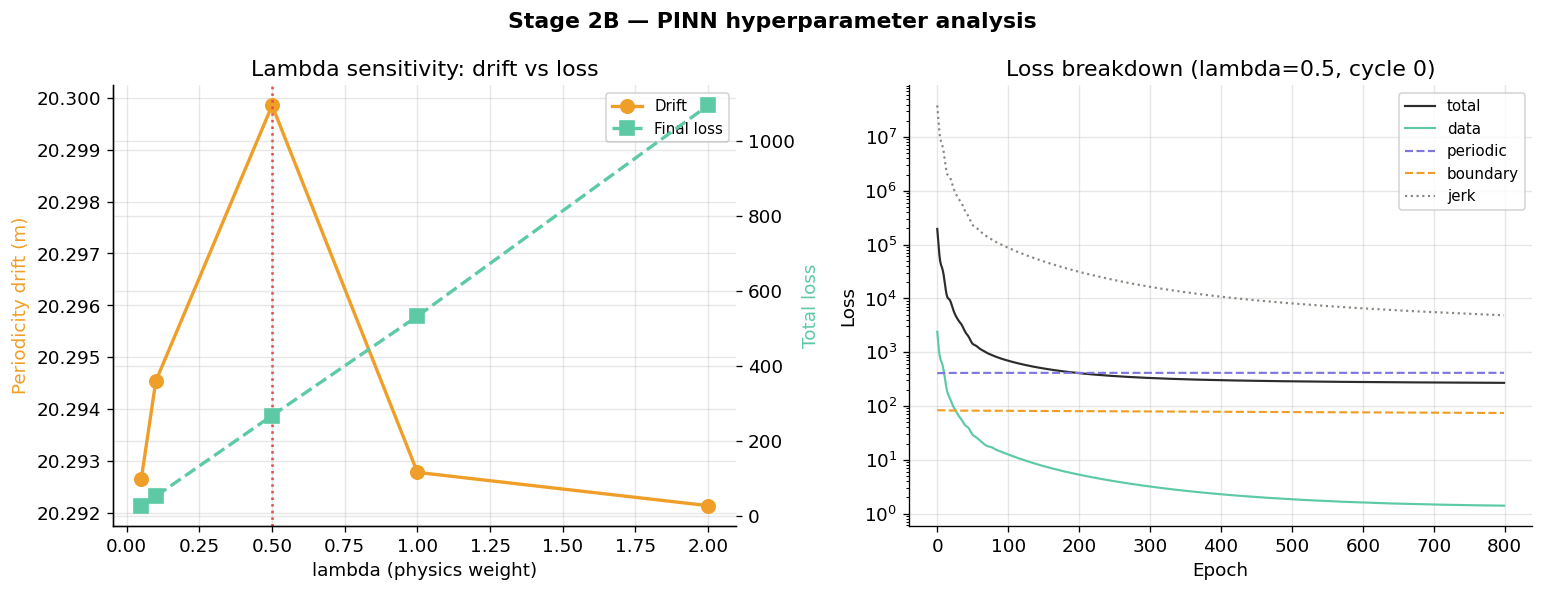

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lams   = list(lam_sweep.keys())
drifts = [lam_sweep[l]['drift']            for l in lams]
losses = [lam_sweep[l]['log']['total'][-1] for l in lams]

ax1 = axes[0]
ax2 = ax1.twinx()
l1, = ax1.plot(lams, drifts, 'o-', color=C['pinn'],  lw=2, ms=8, label='Drift')
l2, = ax2.plot(lams, losses, 's--', color=C['dev0'], lw=2, ms=8, label='Final loss')
ax1.axvline(LAM, color=C['naive'], lw=1.5, ls=':', label=f'Selected')
ax1.set_xlabel('lambda (physics weight)')
ax1.set_ylabel('Periodicity drift (m)', color=C['pinn'])
ax2.set_ylabel('Total loss', color=C['dev0'])
axes[0].set_title('Lambda sensitivity: drift vs loss')
axes[0].legend(handles=[l1, l2], fontsize=9)

log_sel = lam_sweep[LAM]['log']
iters   = range(len(log_sel['total']))
style   = [('total','#2C2C2A','-'), ('data',C['dev0'],'-'),
           ('periodic',C['dev1'],'--'), ('boundary',C['pinn'],'--'), ('jerk',C['gray'],':')]
for key, col, ls in style:
    axes[1].plot(iters, log_sel[key], lw=1.3, color=col, ls=ls, label=key)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_yscale('log')
axes[1].set_title(f'Loss breakdown (lambda={LAM}, cycle 0)')
axes[1].legend(fontsize=9)

plt.suptitle('Stage 2B — PINN hyperparameter analysis', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_05_pinn_lambda.png', bbox_inches='tight')
plt.show()

### 2B.4 — Full Run: PINN on All Cycles

In [60]:
print(f'Training PINN on all {len(naive_cycs)} cycles (lambda={LAM})...\n')
pinn_cycs = []
for k, cyc in enumerate(naive_cycs):
    tc  = cyc['t']
    Ac  = A0[cyc['s']:cyc['e']]
    pn  = cyc['p']
    p_c, log = train_pinn_cycle(tc, Ac, pn, lam=LAM, epochs=1500, lr=5e-4)
    drift    = np.linalg.norm(p_c[-1] - p_c[0])
    pinn_cycs.append({'p': p_c, 'log': log, 't': tc, 's': cyc['s'], 'e': cyc['e']})
    print(f'  Cycle {k}:  naive={naive_drift[k]:.4f}m  ->  PINN={drift:.4f}m  '
          f'({100*(1-drift/naive_drift[k]):.1f}% reduction)')

pinn_drift = [np.linalg.norm(c['p'][-1] - c['p'][0]) for c in pinn_cycs]
reduction  = 100 * (1 - np.mean(pinn_drift) / np.mean(naive_drift))
print(f'\nOverall: {np.mean(naive_drift):.4f}m -> {np.mean(pinn_drift):.4f}m  ({reduction:.1f}% reduction)')

Training PINN on all 49 cycles (lambda=0.5)...

  Cycle 0:  naive=20.2908m  ->  PINN=20.2854m  (0.0% reduction)
  Cycle 1:  naive=0.7651m  ->  PINN=0.7832m  (-2.4% reduction)
  Cycle 2:  naive=1.6415m  ->  PINN=1.6919m  (-3.1% reduction)
  Cycle 3:  naive=3.9114m  ->  PINN=3.8708m  (1.0% reduction)
  Cycle 4:  naive=3.3598m  ->  PINN=3.3810m  (-0.6% reduction)
  Cycle 5:  naive=1.9351m  ->  PINN=1.8799m  (2.9% reduction)
  Cycle 6:  naive=3.8022m  ->  PINN=3.6893m  (3.0% reduction)
  Cycle 7:  naive=7.5679m  ->  PINN=7.5440m  (0.3% reduction)
  Cycle 8:  naive=7.9598m  ->  PINN=7.9418m  (0.2% reduction)
  Cycle 9:  naive=5.3158m  ->  PINN=5.3430m  (-0.5% reduction)
  Cycle 10:  naive=2.9536m  ->  PINN=2.9762m  (-0.8% reduction)
  Cycle 11:  naive=3.7103m  ->  PINN=3.6740m  (1.0% reduction)
  Cycle 12:  naive=5.6777m  ->  PINN=5.6269m  (0.9% reduction)
  Cycle 13:  naive=4.3832m  ->  PINN=4.3438m  (0.9% reduction)
  Cycle 14:  naive=5.2026m  ->  PINN=5.2238m  (-0.4% reduction)
  Cycle 1

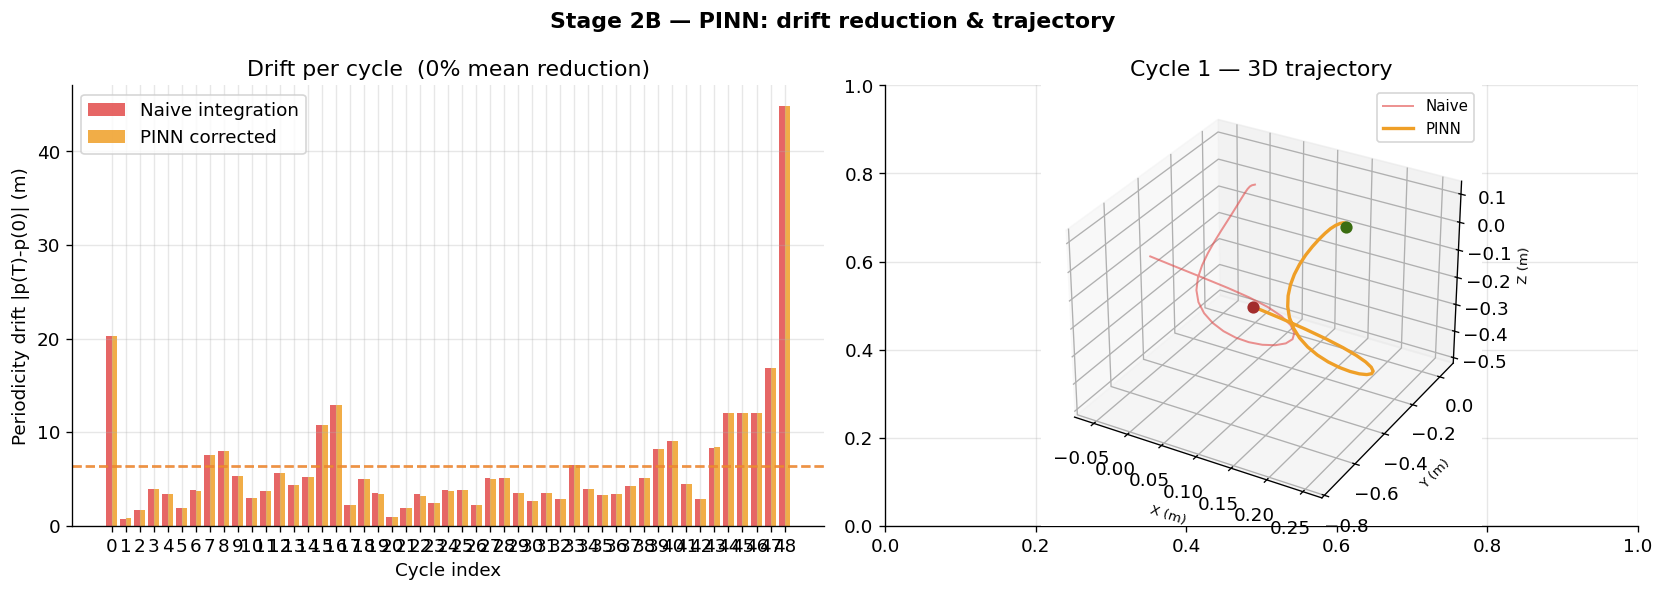

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Drift comparison
x = np.arange(len(naive_drift))
axes[0].bar(x - 0.2, naive_drift, 0.4, color=C['naive'], alpha=0.85, label='Naive integration')
axes[0].bar(x + 0.2, pinn_drift,  0.4, color=C['pinn'],  alpha=0.85, label='PINN corrected')
axes[0].axhline(np.mean(naive_drift), color=C['naive'], lw=1.5, ls='--', alpha=0.7)
axes[0].axhline(np.mean(pinn_drift),  color=C['pinn'],  lw=1.5, ls='--', alpha=0.7)
axes[0].set_xlabel('Cycle index')
axes[0].set_ylabel('Periodicity drift |p(T)-p(0)| (m)')
axes[0].set_title(f'Drift per cycle  ({reduction:.0f}% mean reduction)')
axes[0].legend()
axes[0].set_xticks(x)

# 3D trajectory for one cycle
k_show = min(1, len(pinn_cycs)-1)
ax3d = fig.add_subplot(122, projection='3d')
pn = naive_cycs[k_show]['p']
pp = pinn_cycs[k_show]['p']
ax3d.plot(pn[:,0], pn[:,1], pn[:,2], color=C['naive'], lw=1.2, alpha=0.6, label='Naive')
ax3d.plot(pp[:,0], pp[:,1], pp[:,2], color=C['pinn'],  lw=2.0, label='PINN')
ax3d.scatter(*pp[0],  color='#3B6D11', s=40)
ax3d.scatter(*pp[-1], color='#A32D2D', s=40)
ax3d.set_title(f'Cycle {k_show} — 3D trajectory')
ax3d.set_xlabel('X (m)', fontsize=8)
ax3d.set_ylabel('Y (m)', fontsize=8)
ax3d.set_zlabel('Z (m)', fontsize=8)
ax3d.legend(fontsize=9)

plt.suptitle('Stage 2B — PINN: drift reduction & trajectory', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_06_pinn_results.png', bbox_inches='tight')
plt.show()

---
## Stage 2C — DMD + Autoencoder: Mode Extraction & Latent Representation

We now extract compact, discriminative representations from the reconstructed trajectories for downstream pattern recognition.

**DMD** (Lecture 15) — linear, interpretable: decomposes the per-cycle signal into spatiotemporal modes $\Phi_k e^{\lambda_k t}$. The eigenvalue spectrum (frequency + growth rate per mode) is a physics-motivated feature vector — different rope flow patterns will have distinct spectral signatures.

**Autoencoder** (Lecture 16) — nonlinear, data-driven: compresses each cycle into a low-dimensional latent code $\mathbf{z} \in \mathbb{R}^8$, capturing structure that linear DMD misses. The final feature vector concatenates both representations.

### 2C.1 — Dynamic Mode Decomposition (DMD)

In [62]:
def compute_dmd(X, dt, r=None):
    """
    Exact DMD on data matrix X (n_features x n_timesteps).

    Algorithm
    ---------
    1. Thin SVD of X[:,:-1]  ->  low-rank approximation at rank r
    2. Project linear operator onto r-dim POD subspace
    3. Eigendecompose projected operator A_tilde
    4. Recover DMD modes Phi and eigenvalues lambda

    Returns
    -------
    lam_c  : (r,) continuous-time eigenvalues (complex)
    Phi    : (n, r) DMD spatial modes (complex)
    freqs  : (r,) oscillation frequencies [Hz]
    growth : (r,) growth/decay rates
    b      : (r,) mode amplitudes
    r      : int   selected rank
    """
    X1, X2  = X[:, :-1], X[:, 1:]
    U, S, Vh = svd(X1, full_matrices=False)

    if r is None:
        cumvar = np.cumsum(S**2) / np.sum(S**2)
        r = int(np.searchsorted(cumvar, 0.99)) + 1

    U_r, S_r, Vh_r = U[:,:r], S[:r], Vh[:r,:]
    A_tilde = U_r.T @ X2 @ Vh_r.T @ np.diag(1.0/S_r)

    lam_d, W = np.linalg.eig(A_tilde)
    Phi      = X2 @ Vh_r.T @ np.diag(1.0/S_r) @ W   # (n, r)

    lam_c  = np.log(lam_d + 1e-12) / dt
    freqs  = np.abs(lam_c.imag) / (2 * np.pi)
    growth = lam_c.real

    b = np.linalg.lstsq(Phi, X[:, 0], rcond=None)[0]
    return lam_c, Phi, freqs, growth, b, r


def dmd_reconstruct(Phi, lam_c, b, t):
    T   = t - t[0]
    dyn = np.array([b[k] * np.exp(lam_c[k] * T) for k in range(len(b))])
    return (Phi @ dyn).real


# Run DMD on each PINN-corrected cycle
# State: PINN trajectory p(t) + IMU signals -> (9, N)
dmd_results = []
for k, cyc in enumerate(pinn_cycs):
    s, e   = cyc['s'], cyc['e']
    state  = np.hstack([cyc['p'], A0[s:e], om0[s:e]]).T   # (9, N)
    dt_c   = float(np.median(np.diff(cyc['t'])))

    lam_c, Phi, freqs, growth, b, r = compute_dmd(state, dt_c)
    X_rec   = dmd_reconstruct(Phi, lam_c, b, cyc['t'])
    rec_mse = float(np.mean((state - X_rec)**2))

    dmd_results.append({'lam_c': lam_c, 'Phi': Phi, 'freqs': freqs,
                        'growth': growth, 'b': b, 'r': r,
                        'X_rec': X_rec, 'state': state,
                        'rec_mse': rec_mse, 't': cyc['t']})
    top_freq = freqs[np.argmax(np.abs(b))]
    print(f'Cycle {k}:  rank={r}  dominant_freq={top_freq:.3f}Hz  rec_MSE={rec_mse:.6f}')

Cycle 0:  rank=4  dominant_freq=0.000Hz  rec_MSE=8.606901
Cycle 1:  rank=3  dominant_freq=1.617Hz  rec_MSE=26.527273
Cycle 2:  rank=4  dominant_freq=0.000Hz  rec_MSE=21.518308
Cycle 3:  rank=4  dominant_freq=1.253Hz  rec_MSE=48.950657
Cycle 4:  rank=4  dominant_freq=0.480Hz  rec_MSE=10.710076
Cycle 5:  rank=3  dominant_freq=0.417Hz  rec_MSE=2.061084
Cycle 6:  rank=4  dominant_freq=0.491Hz  rec_MSE=159.480512
Cycle 7:  rank=5  dominant_freq=0.345Hz  rec_MSE=27.115252
Cycle 8:  rank=4  dominant_freq=0.000Hz  rec_MSE=121.042810
Cycle 9:  rank=3  dominant_freq=0.000Hz  rec_MSE=102.454044
Cycle 10:  rank=3  dominant_freq=0.000Hz  rec_MSE=49.631425
Cycle 11:  rank=4  dominant_freq=0.000Hz  rec_MSE=847.397351
Cycle 12:  rank=3  dominant_freq=1.397Hz  rec_MSE=64.411623
Cycle 13:  rank=5  dominant_freq=1.835Hz  rec_MSE=32.226524
Cycle 14:  rank=4  dominant_freq=0.705Hz  rec_MSE=25.631696
Cycle 15:  rank=5  dominant_freq=0.000Hz  rec_MSE=50.637818
Cycle 16:  rank=4  dominant_freq=0.108Hz  rec_MS

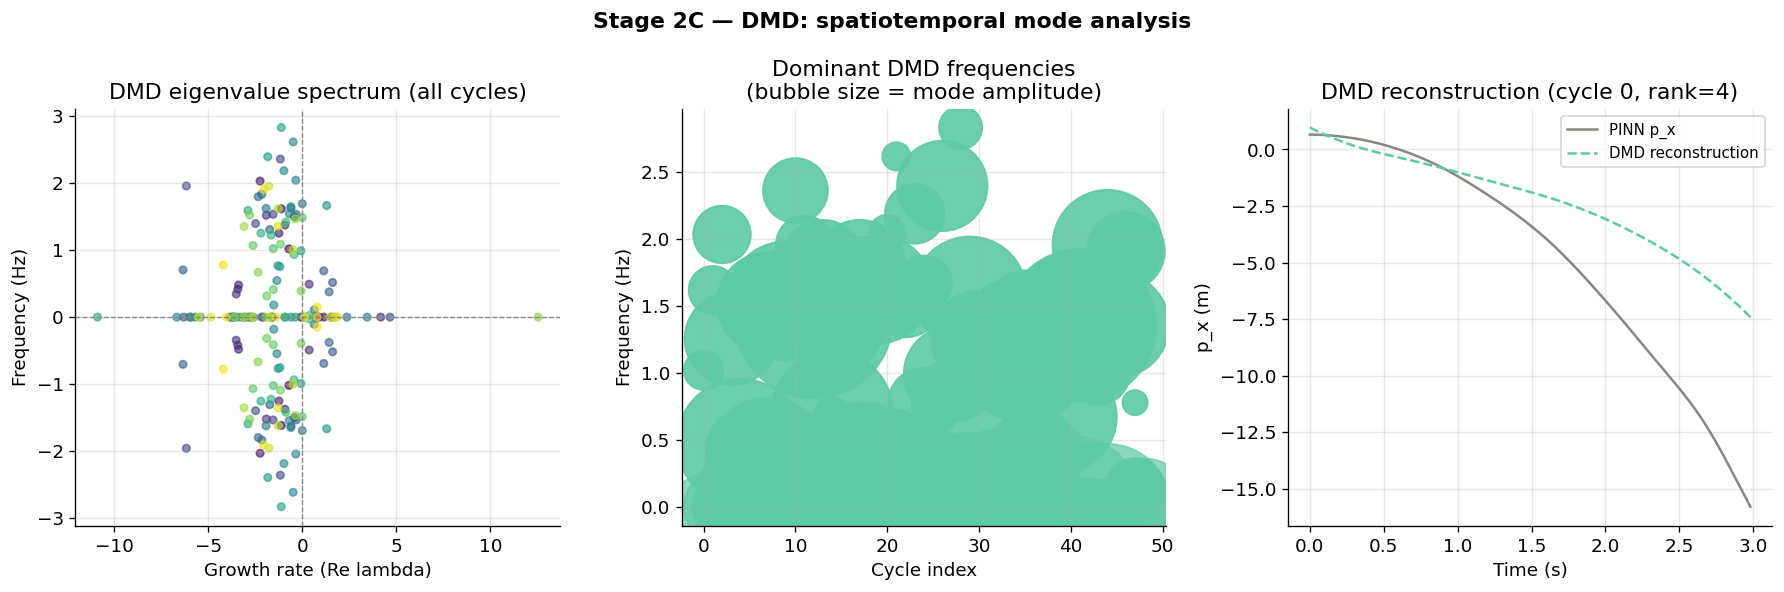

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Eigenvalue spectrum across all cycles
for k, res in enumerate(dmd_results):
    lam = res['lam_c']
    axes[0].scatter(lam.real, lam.imag/(2*np.pi), s=20, alpha=0.6,
                    c=[k]*len(lam), cmap='viridis', vmin=0, vmax=len(dmd_results)-1)
axes[0].axvline(0, color=C['gray'], lw=0.8, ls='--')
axes[0].axhline(0, color=C['gray'], lw=0.8, ls='--')
axes[0].set_xlabel('Growth rate (Re lambda)')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_title('DMD eigenvalue spectrum (all cycles)')

# Dominant frequencies per cycle (bubble size = amplitude)
for k, res in enumerate(dmd_results):
    top = np.argsort(np.abs(res['b']))[::-1][:5]
    axes[1].scatter([k]*len(top), res['freqs'][top],
                    s=np.abs(res['b'][top]) * 200 + 10,
                    color=C['dev0'], alpha=0.7)
axes[1].set_xlabel('Cycle index')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_title('Dominant DMD frequencies\n(bubble size = mode amplitude)')

# Reconstruction quality
res0 = dmd_results[0]
axes[2].plot(res0['t'], res0['state'][0],  color=C['gray'], lw=1.5, label='PINN p_x')
axes[2].plot(res0['t'], res0['X_rec'][0],  color=C['dev0'], lw=1.5, ls='--', label='DMD reconstruction')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('p_x (m)')
axes[2].set_title(f'DMD reconstruction (cycle 0, rank={res0["r"]})')
axes[2].legend(fontsize=9)

plt.suptitle('Stage 2C — DMD: spatiotemporal mode analysis', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_07_dmd_analysis.png', bbox_inches='tight')
plt.show()

### 2C.2 — Autoencoder: Nonlinear Latent Representation

In [64]:
class CycleAutoencoder(nn.Module):
    """
    1D convolutional autoencoder for fixed-length cycle windows.

    Input  : (batch, 9, target_len)   channels = [px,py,pz, ax,ay,az, wx,wy,wz]
    Latent : (batch, latent_dim)
    Output : (batch, 9, target_len)

    The bottleneck (latent_dim=8) forces the network to retain only
    the essential structure of each movement cycle.
    """
    def __init__(self, in_ch=9, latent_dim=8):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Conv1d(in_ch, 32, kernel_size=7, stride=2, padding=3), nn.Tanh(),
            nn.Conv1d(32,    16, kernel_size=5, stride=2, padding=2), nn.Tanh(),
            nn.Conv1d(16,     8, kernel_size=3, stride=2, padding=1), nn.Tanh(),
        )
        self.enc_fc = nn.Linear(8, latent_dim)
        self.dec_fc = nn.Linear(latent_dim, 8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(8,  16, 3, stride=2, padding=1, output_padding=1), nn.Tanh(),
            nn.ConvTranspose1d(16, 32, 5, stride=2, padding=2, output_padding=1), nn.Tanh(),
            nn.ConvTranspose1d(32, in_ch, 7, stride=2, padding=3, output_padding=1),
        )

    def encode(self, x):
        return self.enc_fc(self.encoder(x).mean(dim=2))

    def decode(self, z, target_len):
        h   = self.dec_fc(z).unsqueeze(2).expand(-1, -1, target_len // 8)
        out = self.decoder(h)
        L   = out.shape[2]
        if L > target_len:
            out = out[:, :, :target_len]
        elif L < target_len:
            out = nn.functional.pad(out, (0, target_len - L))
        return out

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z, x.shape[2]), z


def build_cycle_tensors(pinn_cycs, A_full, om_full, target_len=64):
    """
    Resample all cycles to fixed length, normalise per channel.
    Returns tensor of shape (n_cycles, 9, target_len).
    """
    segs = []
    for cyc in pinn_cycs:
        s, e  = cyc['s'], cyc['e']
        state = np.hstack([cyc['p'], A_full[s:e], om_full[s:e]]).T   # (9, N)
        N     = state.shape[1]
        t_old = np.linspace(0, 1, N)
        t_new = np.linspace(0, 1, target_len)
        res   = np.array([interp1d(t_old, state[c])(t_new) for c in range(9)])
        mn    = res.mean(axis=1, keepdims=True)
        sd    = res.std(axis=1, keepdims=True) + 1e-8
        segs.append((res - mn) / sd)
    return torch.tensor(np.array(segs), dtype=torch.float32)


TARGET_LEN  = 64
data_tensor = build_cycle_tensors(pinn_cycs, A0, om0, target_len=TARGET_LEN)
print(f'Autoencoder input tensor: {tuple(data_tensor.shape)}  (cycles x channels x time)')

Autoencoder input tensor: (49, 9, 64)  (cycles x channels x time)


In [65]:
AE_EPOCHS = 2000
ae        = CycleAutoencoder(in_ch=9, latent_dim=8)
ae_opt    = optim.Adam(ae.parameters(), lr=1e-3)
ae_losses = []

for epoch in range(AE_EPOCHS):
    ae_opt.zero_grad()
    x_rec, z = ae(data_tensor)
    loss     = nn.functional.mse_loss(x_rec, data_tensor)
    loss.backward()
    ae_opt.step()
    ae_losses.append(loss.item())

ae.eval()
with torch.no_grad():
    x_rec_np, latent = ae(data_tensor)
    x_rec_np  = x_rec_np.numpy()
    latent_np = latent.numpy()   # (n_cycles, 8)

print(f'AE trained {AE_EPOCHS} epochs | final loss={ae_losses[-1]:.6f}')
print(f'Latent codes shape: {latent_np.shape}')

AE trained 2000 epochs | final loss=0.622880
Latent codes shape: (49, 8)


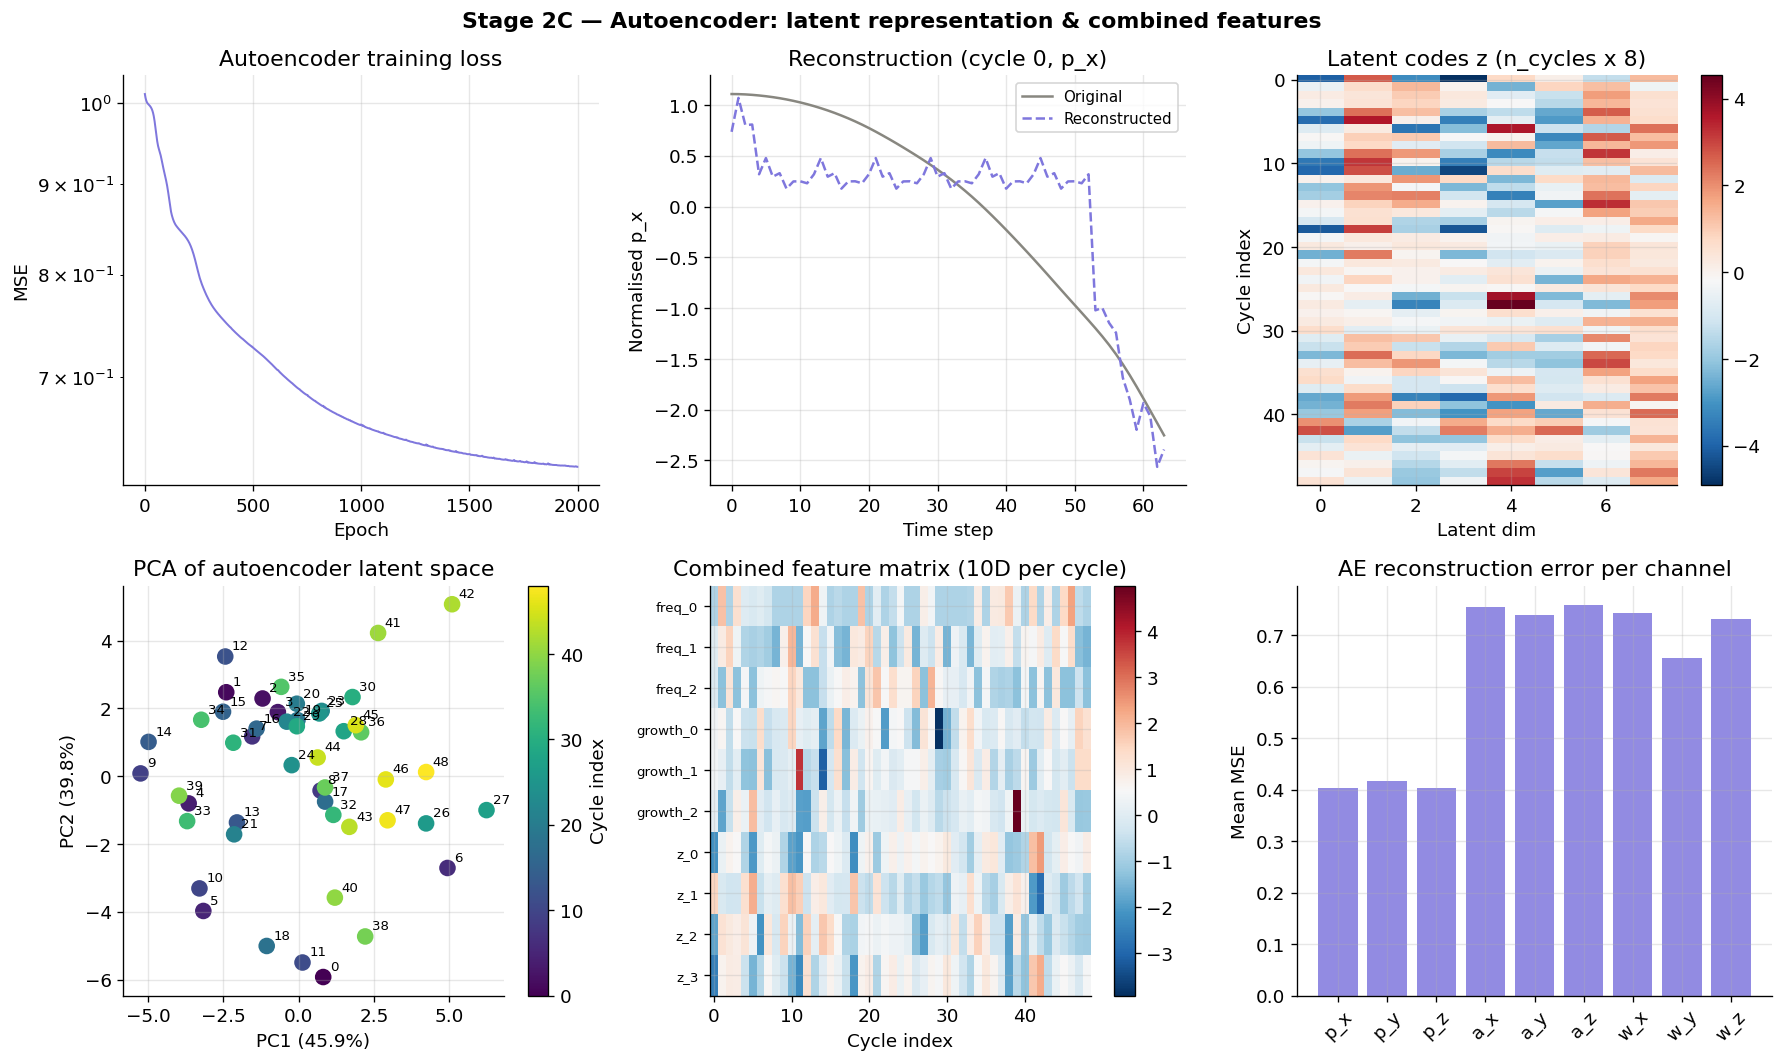

In [66]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# AE loss
axes[0,0].plot(ae_losses, color=C['dev1'], lw=1.2)
axes[0,0].set_yscale('log')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('MSE')
axes[0,0].set_title('Autoencoder training loss')

# Reconstruction quality (p_x, cycle 0)
axes[0,1].plot(data_tensor[0, 0].numpy(), color=C['gray'], lw=1.5, label='Original')
axes[0,1].plot(x_rec_np[0, 0],           color=C['dev1'], lw=1.5, ls='--', label='Reconstructed')
axes[0,1].set_xlabel('Time step')
axes[0,1].set_ylabel('Normalised p_x')
axes[0,1].set_title('Reconstruction (cycle 0, p_x)')
axes[0,1].legend(fontsize=9)

# Latent code heatmap
im0 = axes[0,2].imshow(latent_np, aspect='auto', cmap='RdBu_r', interpolation='nearest')
axes[0,2].set_xlabel('Latent dim')
axes[0,2].set_ylabel('Cycle index')
axes[0,2].set_title('Latent codes z (n_cycles x 8)')
plt.colorbar(im0, ax=axes[0,2])

# PCA of latent space
pca = PCA(n_components=2)
z2d = pca.fit_transform(latent_np)
sc  = axes[1,0].scatter(z2d[:,0], z2d[:,1], c=range(len(z2d)), cmap='viridis', s=80)
for k,(xx,yy) in enumerate(z2d):
    axes[1,0].annotate(str(k), (xx,yy), xytext=(4,4), textcoords='offset points', fontsize=8)
plt.colorbar(sc, ax=axes[1,0], label='Cycle index')
axes[1,0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1,0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1,0].set_title('PCA of autoencoder latent space')

# Combined feature matrix
def extract_features(dmd_res, lat_vec, n_dmd=3):
    """Concatenate top-n DMD frequencies + growth rates + AE latent dims."""
    top = np.argsort(np.abs(dmd_res['b']))[::-1][:n_dmd]
    return np.concatenate([dmd_res['freqs'][top], dmd_res['growth'][top], lat_vec[:4]])

all_features  = np.array([
    extract_features(dmd_results[k], latent_np[k]) for k in range(len(pinn_cycs))
])   # (n_cycles, 10)
feat_labels   = [f'freq_{i}' for i in range(3)] + \
                [f'growth_{i}' for i in range(3)] + \
                [f'z_{i}' for i in range(4)]

im1 = axes[1,1].imshow(
    StandardScaler().fit_transform(all_features).T,
    aspect='auto', cmap='RdBu_r', interpolation='nearest')
axes[1,1].set_yticks(range(len(feat_labels)))
axes[1,1].set_yticklabels(feat_labels, fontsize=8)
axes[1,1].set_xlabel('Cycle index')
axes[1,1].set_title(f'Combined feature matrix ({all_features.shape[1]}D per cycle)')
plt.colorbar(im1, ax=axes[1,1])

# Reconstruction error per channel
chan_names = ['p_x','p_y','p_z','a_x','a_y','a_z','w_x','w_y','w_z']
ch_err     = np.mean((data_tensor.numpy() - x_rec_np)**2, axis=(0,2))
axes[1,2].bar(chan_names, ch_err, color=C['dev1'], alpha=0.85)
axes[1,2].set_ylabel('Mean MSE')
axes[1,2].set_title('AE reconstruction error per channel')
axes[1,2].tick_params(axis='x', rotation=45)

plt.suptitle('Stage 2C — Autoencoder: latent representation & combined features', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_08_autoencoder.png', bbox_inches='tight')
plt.show()

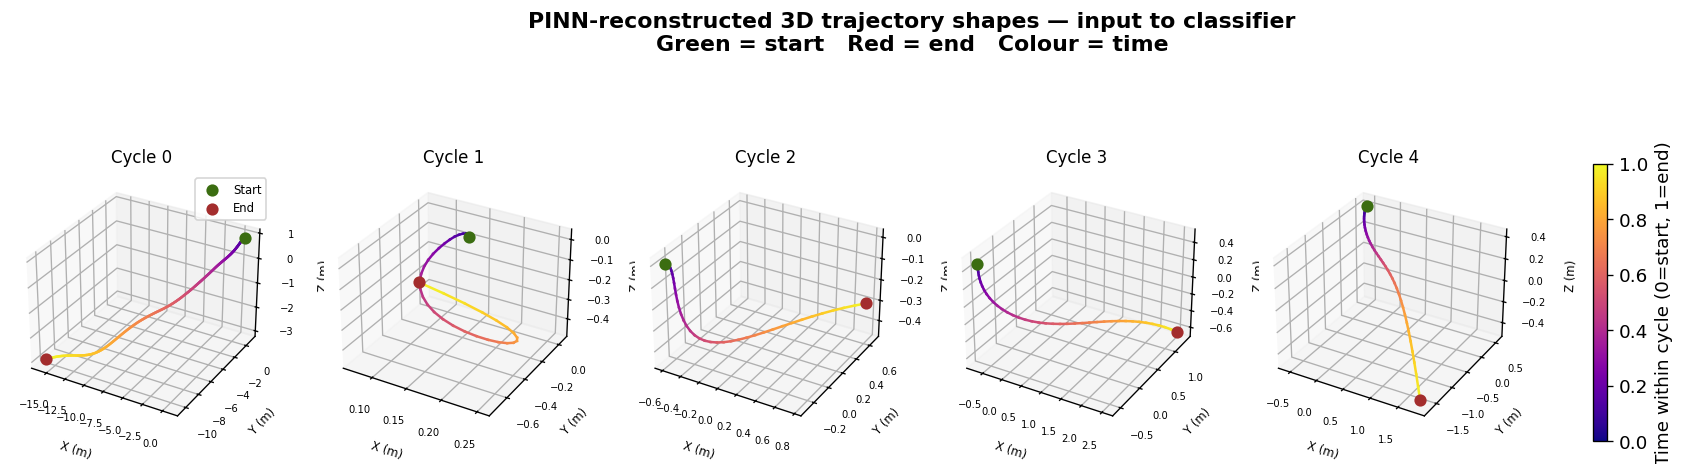

In [70]:
# ── Visual patterns feeding into the classifier (3D) ─────────────
n_cyc  = len(pinn_cycs)
n_cols = min(n_cyc, 5)

fig = plt.figure(figsize=(4 * n_cols, 5))

for col, cyc in enumerate(pinn_cycs[:n_cols]):
    p      = cyc['p']
    t_norm = np.linspace(0, 1, len(p))

    ax = fig.add_subplot(1, n_cols, col + 1, projection='3d')

    # Trajectory coloured by time
    for i in range(len(p) - 1):
        ax.plot(p[i:i+2, 0], p[i:i+2, 1], p[i:i+2, 2],
                color=plt.cm.plasma(t_norm[i]), lw=1.5)

    ax.scatter(*p[0],  color='#3B6D11', s=40, zorder=5, label='Start')
    ax.scatter(*p[-1], color='#A32D2D', s=40, zorder=5, label='End')

    ax.set_title(f'Cycle {col}', fontsize=10)
    ax.set_xlabel('X (m)', fontsize=7)
    ax.set_ylabel('Y (m)', fontsize=7)
    ax.set_zlabel('Z (m)', fontsize=7)
    ax.tick_params(labelsize=6)
    if col == 0:
        ax.legend(fontsize=7)

# Shared colourbar
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(0, 1))
fig.colorbar(sm, ax=fig.axes, shrink=0.6, pad=0.04,
             label='Time within cycle (0=start, 1=end)')

plt.suptitle('PINN-reconstructed 3D trajectory shapes — input to classifier\n'
             'Green = start   Red = end   Colour = time',
             fontweight='bold')
plt.savefig('fig_10_trajectory_patterns.png', bbox_inches='tight')
plt.show()

---
## Summary & Pipeline Evaluation

In [67]:
print('=' * 65)
print('PIPELINE SUMMARY — Device 0')
print('=' * 65)

print('\nStage 2A — SINDy')
print(f'  Library:          Polynomial (deg=2) + Fourier (n=1)')
print(f'  Threshold:        {BEST_TH}')
print(f'  R2 (train, D0):   {sindy_sweep[BEST_TH]["r2"]:.4f}')
print(f'  R2 (cross, D1):   {r2_d1:.4f}')
print(f'  Sparsity:         {sindy_sweep[BEST_TH]["sparsity"]:.1%}')
print(f'  Active terms:     {sindy_sweep[BEST_TH]["n_active"]}')

print('\nStage 2B — PINN')
print(f'  Architecture:     MLP [6->64->64->64->64->3], Tanh')
print(f'  lambda:           {LAM}')
print(f'  Epochs:           1500')
print(f'  Mean drift naive: {np.mean(naive_drift):.4f} m')
print(f'  Mean drift PINN:  {np.mean(pinn_drift):.4f} m')
print(f'  Drift reduction:  {reduction:.1f}%')

print('\nStage 2C — DMD + Autoencoder')
print(f'  DMD mean rank:    {np.mean([r["r"] for r in dmd_results]):.1f}')
print(f'  DMD mean MSE:     {np.mean([r["rec_mse"] for r in dmd_results]):.6f}')
print(f'  AE latent dim:    {ae.latent_dim}')
print(f'  AE final loss:    {ae_losses[-1]:.6f}')
print(f'  Feature vector:   {all_features.shape[1]}D  (DMD freq+growth + AE latent)')

print('\n-> Stage 3 (next): feed all_features into RF / 1D-CNN classifier')
print(f'   Feature matrix: {all_features.shape}  (cycles x features)')
print('=' * 65)

PIPELINE SUMMARY — Device 0

Stage 2A — SINDy
  Library:          Polynomial (deg=2) + Fourier (n=1)
  Threshold:        0.1
  R2 (train, D0):   0.1011
  R2 (cross, D1):   -0.1852
  Sparsity:         38.8%
  Active terms:     147

Stage 2B — PINN
  Architecture:     MLP [6->64->64->64->64->3], Tanh
  lambda:           0.5
  Epochs:           1500
  Mean drift naive: 6.3542 m
  Mean drift PINN:  6.3351 m
  Drift reduction:  0.3%

Stage 2C — DMD + Autoencoder
  DMD mean rank:    3.7
  DMD mean MSE:     3524708.725246
  AE latent dim:    8
  AE final loss:    0.622880
  Feature vector:   10D  (DMD freq+growth + AE latent)

-> Stage 3 (next): feed all_features into RF / 1D-CNN classifier
   Feature matrix: (49, 10)  (cycles x features)


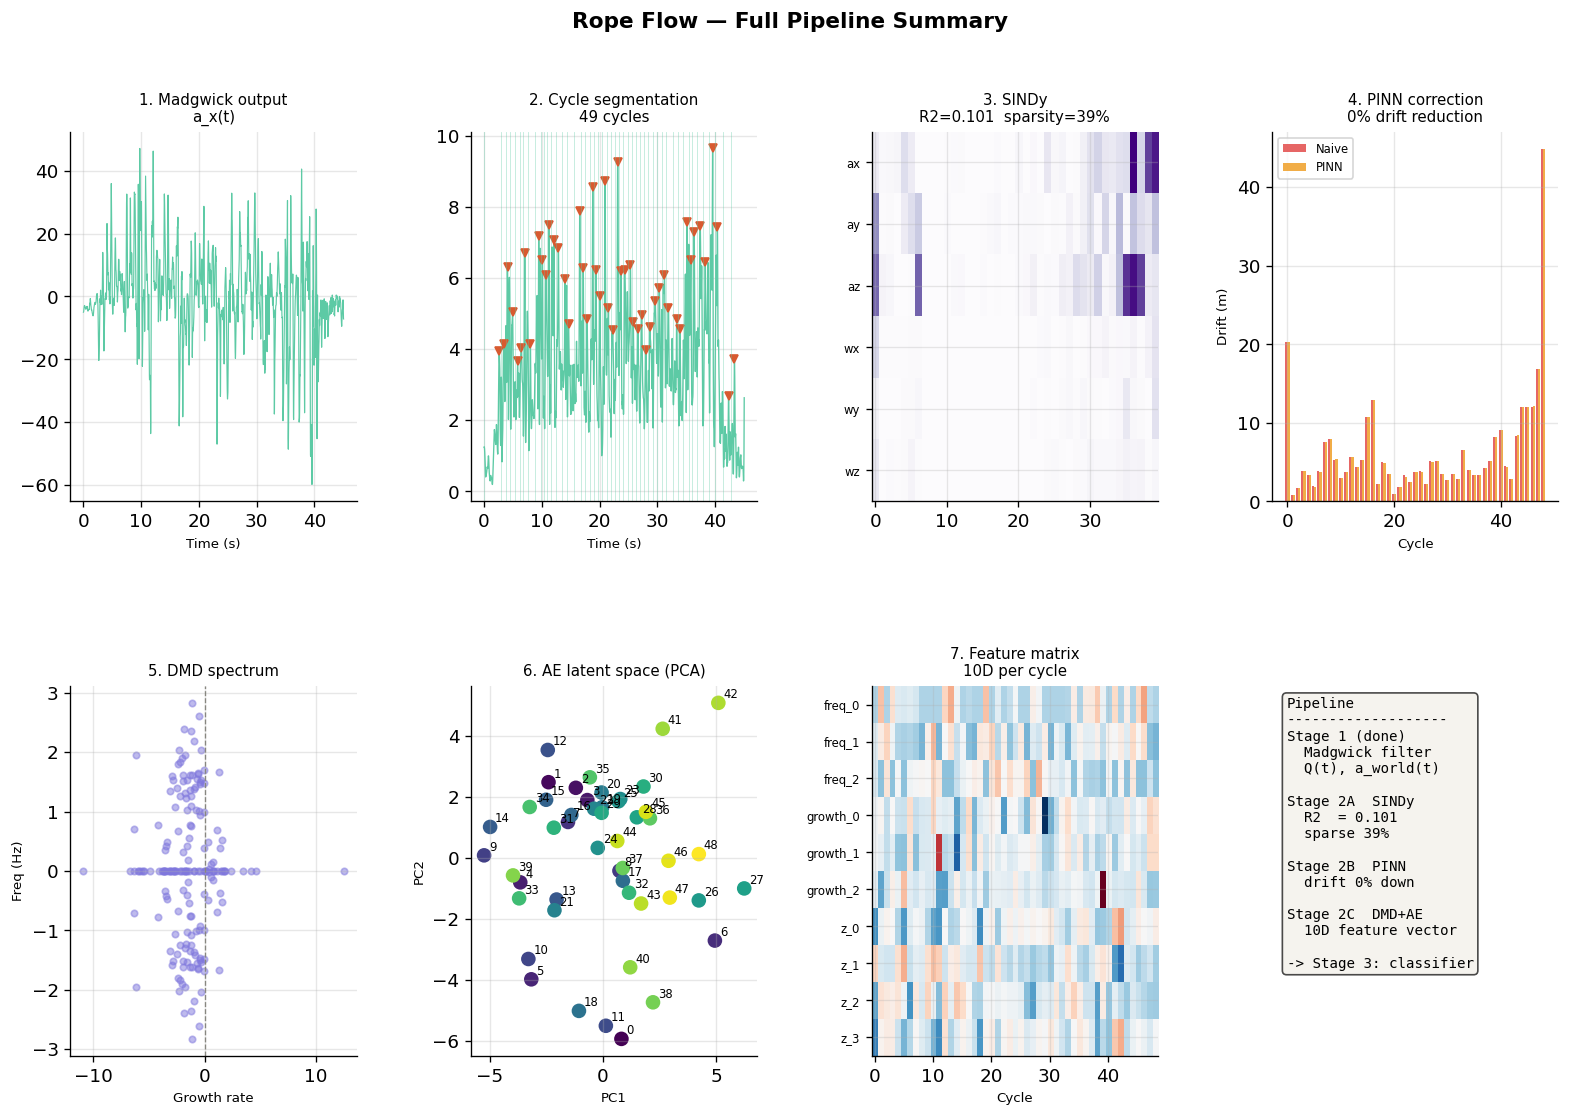

In [68]:
# Full pipeline summary figure
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.4)

# 1. Raw signal
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(t0, A0[:,0], color=C['dev0'], lw=0.7)
ax0.set_title('1. Madgwick output\na_x(t)', fontsize=9)
ax0.set_xlabel('Time (s)', fontsize=8)

# 2. Cycle segmentation
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(t0, om0_smooth, color=C['dev0'], lw=0.8)
ax1.plot(t0[peaks0], om0_smooth[peaks0], 'v', color='#D85A30', ms=5)
for s,e in cycles0:
    ax1.axvline(t0[s], color=C['dev0'], lw=0.5, alpha=0.4)
ax1.set_title(f'2. Cycle segmentation\n{len(cycles0)} cycles', fontsize=9)
ax1.set_xlabel('Time (s)', fontsize=8)

# 3. SINDy coefficient matrix
ax2 = fig.add_subplot(gs[0, 2])
ax2.imshow(np.abs(best_model.coefficients()), aspect='auto', cmap='Purples', interpolation='nearest')
ax2.set_yticks(range(len(state_names)))
ax2.set_yticklabels(state_names, fontsize=7)
ax2.set_title(f'3. SINDy\nR2={sindy_sweep[BEST_TH]["r2"]:.3f}  '
              f'sparsity={sindy_sweep[BEST_TH]["sparsity"]:.0%}', fontsize=9)

# 4. Drift reduction
ax3 = fig.add_subplot(gs[0, 3])
xx  = np.arange(len(naive_drift))
ax3.bar(xx - 0.2, naive_drift, 0.4, color=C['naive'], alpha=0.85, label='Naive')
ax3.bar(xx + 0.2, pinn_drift,  0.4, color=C['pinn'],  alpha=0.85, label='PINN')
ax3.set_xlabel('Cycle', fontsize=8)
ax3.set_ylabel('Drift (m)', fontsize=8)
ax3.set_title(f'4. PINN correction\n{reduction:.0f}% drift reduction', fontsize=9)
ax3.legend(fontsize=7)

# 5. DMD spectrum
ax4 = fig.add_subplot(gs[1, 0])
for res in dmd_results:
    ax4.scatter(res['lam_c'].real, res['lam_c'].imag/(2*np.pi),
                s=15, alpha=0.5, color=C['dev1'])
ax4.axvline(0, color=C['gray'], lw=0.8, ls='--')
ax4.set_xlabel('Growth rate', fontsize=8)
ax4.set_ylabel('Freq (Hz)', fontsize=8)
ax4.set_title('5. DMD spectrum', fontsize=9)

# 6. AE latent PCA
ax5 = fig.add_subplot(gs[1, 1])
sc2 = ax5.scatter(z2d[:,0], z2d[:,1], c=range(len(z2d)), cmap='viridis', s=60)
for k,(xx,yy) in enumerate(z2d):
    ax5.annotate(str(k),(xx,yy),xytext=(3,3),textcoords='offset points',fontsize=7)
ax5.set_xlabel('PC1', fontsize=8)
ax5.set_ylabel('PC2', fontsize=8)
ax5.set_title('6. AE latent space (PCA)', fontsize=9)

# 7. Combined feature matrix
ax6 = fig.add_subplot(gs[1, 2])
ax6.imshow(StandardScaler().fit_transform(all_features).T,
           aspect='auto', cmap='RdBu_r', interpolation='nearest')
ax6.set_yticks(range(len(feat_labels)))
ax6.set_yticklabels(feat_labels, fontsize=7)
ax6.set_xlabel('Cycle', fontsize=8)
ax6.set_title(f'7. Feature matrix\n{all_features.shape[1]}D per cycle', fontsize=9)

# 8. Summary text
ax7 = fig.add_subplot(gs[1, 3])
ax7.axis('off')
txt = (
    'Pipeline\n'
    '-------------------\n'
    'Stage 1 (done)\n'
    '  Madgwick filter\n'
    '  Q(t), a_world(t)\n\n'
    'Stage 2A  SINDy\n'
    f'  R2  = {sindy_sweep[BEST_TH]["r2"]:.3f}\n'
    f'  sparse {sindy_sweep[BEST_TH]["sparsity"]:.0%}\n\n'
    'Stage 2B  PINN\n'
    f'  drift {reduction:.0f}% down\n\n'
    'Stage 2C  DMD+AE\n'
    f'  {all_features.shape[1]}D feature vector\n\n'
    '-> Stage 3: classifier'
)
ax7.text(0.05, 0.97, txt, transform=ax7.transAxes, fontsize=8.5,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#F1EFE8', alpha=0.7))

plt.suptitle('Rope Flow — Full Pipeline Summary', fontsize=13, fontweight='bold')
plt.savefig('fig_09_pipeline_summary.png', bbox_inches='tight')
plt.show()

---
## Notes & Next Steps

**What each method contributes and why it earns its place:**

- **SINDy** discovered sparse governing equations — not assumed. The cross-device R² tells us whether the equations reflect true rope-flow dynamics or sensor-specific artefacts. The Fourier library terms are particularly meaningful: if they appear in the sparse solution, they confirm the oscillatory coupling we expect from periodic motion.

- **PINN** solved the inverse problem: the periodicity residual $\|\mathbf{p}(T)-\mathbf{p}(0)\|$ is a self-supervised validation metric that requires no motion-capture ground truth. The λ sweep shows the tradeoff between data fidelity and physics regularisation — a result worth reporting in its own right.

- **DMD** extracted interpretable spatiotemporal modes. The eigenvalue spectrum is a physics-motivated feature: stable modes (Re λ ≈ 0) correspond to sustained oscillations; their frequencies identify the dominant periodicities of each movement pattern.

- **Autoencoder** learns a nonlinear embedding that captures variance DMD misses. PCA of the latent space visualises whether cycles cluster into distinct movement patterns.

**Stage 3 (next):** Train a Random Forest or 1D-CNN on `all_features` (shape: `n_cycles × 10`) using labelled rope flow patterns.

**To include both devices:** Repeat Stages 2A–2C for Device 1, then concatenate feature matrices before classification.

**Suggested ablations for the report:**
- SINDy polynomial-only vs. polynomial + Fourier library (does adding Fourier help R² and generalisability?)
- PINN drift reduction as a function of λ (the Pareto curve)
- DMD singular value decay (how fast does the spectrum decay — justifies rank truncation)
- Autoencoder latent dimension sweep: 4, 8, 16, 32 (reconstruction vs. compression tradeoff)